# Лабораторная работа 11

Тема: **Автоэнкодер для изображений MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук специально оформлен так, чтобы **нельзя было сделать отчёт простым копированием чужого кода или ответов генеративной модели**.  
> Каркас кода даёт вам рабочий пример, но оцениваться будут **ваши** настройки, эксперименты и живые текстовые объяснения.


## 1. Ваши ожидания от автоэнкодера

Перед запуском кода сформулируйте текущие ожидания (6–10 предложений):

1. Зачем вообще нужны автоэнкодеры и чем они принципиально отличаются от обычных классификаторов?
2. Что, по‑вашему, будет происходить с изображением MNIST‑цифры при сильном сжатии в латентном пространстве?  
3. Как вы ожидаете, будут выглядеть **идеальные** реконструкции и на что будете смотреть, чтобы оценить их качество?

In [1]:
intro_text = """1)Автоэнкодер используется для автоматического обучения, в котором данные можно сжимать и разжимать.
Он используется для уменьшения размерности или сжатия данных, а также для удаления шума с изображений
Его отличие от обычного классификатора в том, что автоэнкдор учится без учителя, а классификатор - с учителем.
Также он извлекает признаки, а классификатор делит на классы.

2)При сильно сжатии изображений MNIST, будут сохарняться наиболее важные признаки цифр: формы или контуры.
Более мелкие детали будут теряться, что может привести к сильному искажению.

3)Идеальные реконструкции думаю будут выглядет близко похожими на оригинальные картинки, которые сможет различить человек.
Чтобы оценить их качесатво буду смотреть на четкость контуров, а также на сохранение особенностей цифр.

"""
print(intro_text)

1)Автоэнкодер используется для автоматического обучения, в котором данные можно сжимать и разжимать. 
Он используется для уменьшения размерности или сжатия данных, а также для удаления шума с изображений 
Его отличие от обычного классификатора в том, что автоэнкдор учится без учителя, а классификатор - с учителем.
Также он извлекает признаки, а классификатор делит на классы.

2)При сильно сжатии изображений MNIST, будут сохарняться наиболее важные признаки цифр: формы или контуры.
Более мелкие детали будут теряться, что может привести к сильному искажению.

3)Идеальные реконструкции думаю будут выглядет близко похожими на оригинальные картинки, которые сможет различить человек. 
Чтобы оценить их качесатво буду смотреть на четкость контуров, а также на сохранение особенностей цифр. 




## 2. Импорт библиотек и настройка среды


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

MY_SEED = 22  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 22


## 3. Данные MNIST и DataLoader

Используем стандартный MNIST (28×28, оттенки серого).  
Автоэнкодер будет учиться восстанавливать картинку **самой себя**.


In [3]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

Размер train: 60000
Размер test : 10000


Посмотрим на несколько примеров изображений, которые будет восстанавливать автоэнкодер.


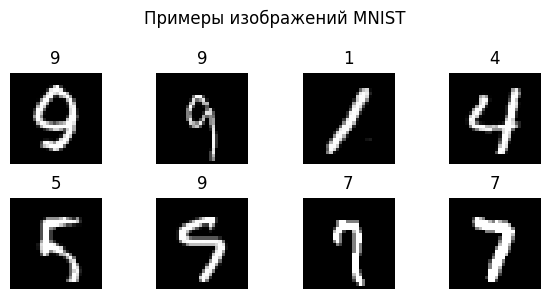

In [4]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным

Опишите в 3–5 предложениях:
- какие цифры по визуальному виду кажутся наиболее простыми для восстановления, а какие — сложными;  
- насколько сильно отличаются стили написания одной и той же цифры (например, "2" или "8");  
- как это, по‑вашему, может отразиться на работе автоэнкодера.


In [5]:
data_comment = """Для меня по визуальному виду цифры 0, 2, 3, 4, 8 кажутся наиболее простыми, поскольку имеют свои отличительные признаки, которые тяжело спутать.
Написание, например, цифры 7 отоичается чаще всего. Где-то есть черта, где-то нету.
Без черты очень часто сложно отличить от цифры 1, особенно если цифра написана криво.
Думаю, что на работе энкодера именно эта цифра окажется самой сложной, так как ему необходимо научиться восстанавливать обобщённый образ цифры, игнорируя индивидуальные особенности почерка.
"""
print(data_comment)

Для меня по визуальному виду цифры 0, 2, 3, 4, 8 кажутся наиболее простыми, поскольку имеют свои отличительные признаки, которые тяжело спутать.
Написание, например, цифры 7 отоичается чаще всего. Где-то есть черта, где-то нету.
Без черты очень часто сложно отличить от цифры 1, особенно если цифра написана криво. 
Думаю, что на работе энкодера именно эта цифра окажется самой сложной, так как ему необходимо научиться восстанавливать обобщённый образ цифры, игнорируя индивидуальные особенности почерка. 



## 4. Архитектура простого полносвязного автоэнкодера

Будем работать с векторизованным изображением размерности 784 (28×28).  
Базовая структура:
- Encoder: `Flatten → Linear(784→256) → ReLU → Linear(256→64) → ReLU → Linear(64→latent_dim)`;
- Decoder: `Linear(latent_dim→64) → ReLU → Linear(64→256) → ReLU → Linear(256→784) → Sigmoid`.

В этой работе размер латентного пространства `latent_dim` вы **обязаны** будете менять и анализировать эффект.


In [6]:
latent_dim = 16 # базовое значение; в отчёте попробуйте хотя бы ещё два

class FCN_Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),  # пиксели в
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### Обсуждение архитектуры

Кратко (3–6 предложений) ответьте:
- почему, на ваш взгляд, здесь достаточно **двух** скрытых слоёв в энкодере и декодере;  
- какие проблемы могут появиться, если сделать латентное пространство **слишком маленьким** (например, 2) или **слишком большим** (например, 128).


In [7]:
arch_comment = """Задача на изображениях MNIST не является слишком сложной, так как изображения маленькие и простые.
Поэтому 2ух скрытых слоев должно быть достаточно, чтобы модель извлекла основные признаки, не усложнив модель, что могло бы привести к переобучению.
Если сделать латентное пространство слишком маленьким, то модель будет слишком сильно сжимать информацию, что может приводить к потере важных деталей и качества реконструкции.
В обратном случае с увеличением, автоэкодер может начать запоминать данные, а не извлекать обобщенные признаки, тогда смысла в автоэнкодере не будет.
"""
print(arch_comment)

Задача на изображениях MNIST не является слишком сложной, так как изображения маленькие и простые.
Поэтому 2ух скрытых слоев должно быть достаточно, чтобы модель извлекла основные признаки, не усложнив модель, что могло бы привести к переобучению.
Если сделать латентное пространство слишком маленьким, то модель будет слишком сильно сжимать информацию, что может приводить к потере важных деталей и качества реконструкции.
В обратном случае с увеличением, автоэкодер может начать запоминать данные, а не извлекать обобщенные признаки, тогда смысла в автоэнкодере не будет.



## 5. Функция потерь, оптимизатор и цикл обучения

Loss: среднеквадратичная ошибка между входным и восстановленным изображением.  
Оптимизатор: Adam с умеренным шагом.


In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [9]:
num_epochs = 15  # в отчёте попробуйте другое число эпох и сравните
history = {"train_loss": [], "test_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")

Эпоха 1/15: train_loss=0.0541, test_loss=0.0325
Эпоха 2/15: train_loss=0.0287, test_loss=0.0255
Эпоха 3/15: train_loss=0.0244, test_loss=0.0228
Эпоха 4/15: train_loss=0.0216, test_loss=0.0202
Эпоха 5/15: train_loss=0.0196, test_loss=0.0184
Эпоха 6/15: train_loss=0.0179, test_loss=0.0167
Эпоха 7/15: train_loss=0.0164, test_loss=0.0156
Эпоха 8/15: train_loss=0.0152, test_loss=0.0145
Эпоха 9/15: train_loss=0.0144, test_loss=0.0139
Эпоха 10/15: train_loss=0.0137, test_loss=0.0132
Эпоха 11/15: train_loss=0.0131, test_loss=0.0126
Эпоха 12/15: train_loss=0.0125, test_loss=0.0121
Эпоха 13/15: train_loss=0.0122, test_loss=0.0120
Эпоха 14/15: train_loss=0.0118, test_loss=0.0117
Эпоха 15/15: train_loss=0.0116, test_loss=0.0114


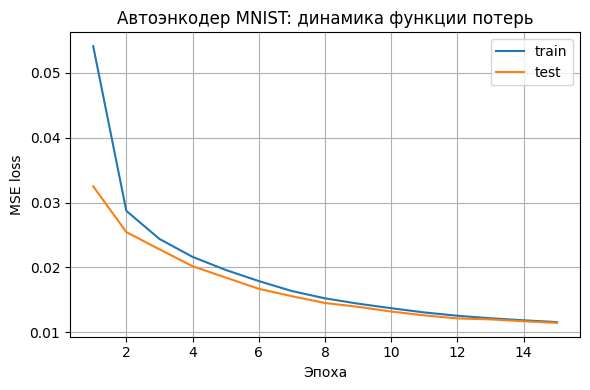

Финальные значения: train_loss=0.0116, test_loss=0.0114


In [10]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Автоэнкодер MNIST: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={history['train_loss'][-1]:.4f}, test_loss={history['test_loss'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- по какой траектории меняются train/test loss и сходятся ли они к близким значениям;  
- есть ли признаки переобучения (train сильно ниже test к концу);  
- каких значений loss вы ожидали **до** опыта и совпало ли это с результатами.


In [11]:
training_comment = """Попробовала обучение на 15 и 25 эпохах. И там, и там loss снижаются хорошо.
Кривая на тесте снижается чуть более плавно на первых 2ух-3ёх эпохах, чем на обучении.
Дальше снижение очень плавное, можно сказать синхронное, к концу обучения train и test loss принимают почти равные значения.
На некоторых эпохах можно заметить, что test даже ниже, чем train, но разница минимальна.
Признаков переобучения нет, так как кривые почти сходятся.
Я ожидала примерно 0,02, но получилось даже меньше.

"""
print(training_comment)

Попробовала обучение на 15 и 25 эпохах. И там, и там loss снижаются хорошо.
Кривая на тесте снижается чуть более плавно на первых 2ух-3ёх эпохах, чем на обучении.
Дальше снижение очень плавное, можно сказать синхронное, к концу обучения train и test loss принимают почти равные значения.
На некоторых эпохах можно заметить, что test даже ниже, чем train, но разница минимальна.
Признаков переобучения нет, так как кривые почти сходятся.
Я ожидала примерно 0,02, но получилось даже меньше.




## 6. Визуализация реконструкций

Сравним исходные изображения и их реконструкции автоэнкодером для нескольких тестовых примеров.


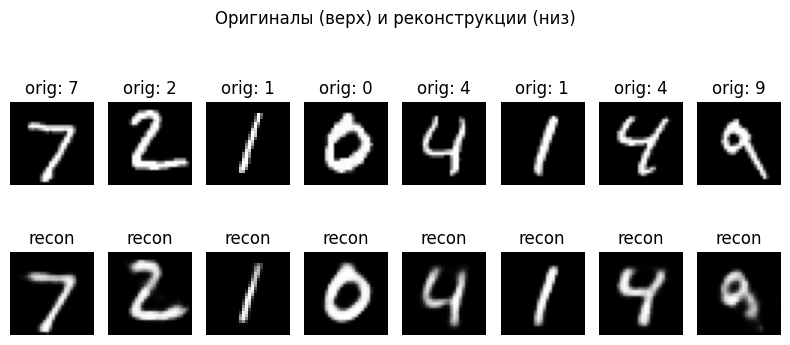

In [12]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    reconstructions, _ = model(images)

images = images.cpu()
reconstructions = reconstructions.cpu()

n = 8
plt.figure(figsize=(8, 4))
for i in range(n):
    # оригинал
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")
    # реконструкция
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructions[i].squeeze(0), cmap="gray")
    plt.title("recon")
    plt.axis("off")
plt.suptitle("Оригиналы (верх) и реконструкции (низ)")
plt.tight_layout()
plt.show()

### Качественная оценка реконструкций

Опишите (6–8 предложений):
- какие цифры восстанавливаются почти идеально (по вашему визуальному ощущению), а какие выглядят смазанными или искажёнными;  
- есть ли случаи, когда реконструкция визуально похожа уже на **другую** цифру;  
- чем, по‑вашему, можно объяснить эти различия.


In [13]:
recon_comment = """По моим визуальным ощущениям все цифры из представленных восстанавились почти идеально, кроме 9.
В некоторых случаях из-за сжатия некоторые линии убрались, поэтому в реконструкции цифры выглядят даже ровнее, чем до.
Не смотря на это, некоторые цифры выглядят смазанными или нечеткими, но их все равно всё еще можно распознать.

Из представленных цифр не наблюдается случаи, когда реконструкция визуально похожа на другую цифру.
Возможно, последняя 9, но она все равно похожа сама на себя.

Исходя из этого, не могу объяснить чем по моему мнению эти различия отличаются.

"""
print(recon_comment)

По моим визуальным ощущениям все цифры из представленных восстанавились почти идеально, кроме 9.
В некоторых случаях из-за сжатия некоторые линии убрались, поэтому в реконструкции цифры выглядят даже ровнее, чем до.
Не смотря на это, некоторые цифры выглядят смазанными или нечеткими, но их все равно всё еще можно распознать.

Из представленных цифр не наблюдается случаи, когда реконструкция визуально похожа на другую цифру.
Возможно, последняя 9, но она все равно похожа сама на себя.

Исходя из этого, не могу объяснить чем по моему мнению эти различия отличаются.




## 7. Латентное пространство: PCA‑проекция в 2D

Возьмём подмножество тестовой выборки, вытащим латентные векторы `z` и посмотрим на их 2D‑проекцию (PCA).  
Цель: увидеть, группируются ли разные цифры в отдельные кластеры.


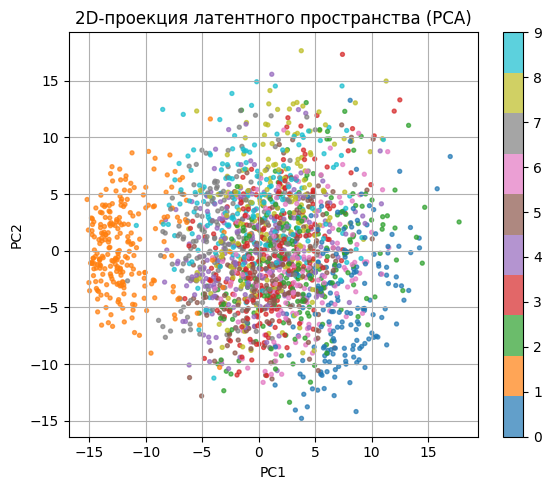

In [14]:
from sklearn.decomposition import PCA

model.eval()
all_z = []
all_y = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_y.append(labels.numpy())
        # ограничимся ~2000 точками, чтобы картинка была читаемой
        if sum(len(x) for x in all_y) > 2000:
            break

Z = np.vstack(all_z)
Y = np.hstack(all_y)

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D‑проекция латентного пространства (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### Интерпретация латентного пространства

Ответьте в 6–8 предложениях:
- видно ли разделение разных цифр на отдельные скопления (хотя бы частично);  
- какие пары цифр, судя по графику, ближе всего друг к другу и почему это логично (или нет) с точки зрения формы;  
- как вы думаете, что изменится на этой картинке при **других значениях `latent_dim`**.


In [15]:
latent_comment = """На 2D‑проекции можно увидеть частичное разделение разных цифр на отдельные скопления.
Это особенно заметно на цифре 1.
Цифра 1 формирует более компактный и отдаленный кластер по сравнению с остальными.
Остальные кластеры лежат друг на друге, в связи с чем их сложнее разлечить между собой.
Я думаю, что при уменьшении latent_dim будет еще более плотное смешивание кластеров, а при увеличении - наоборот, кластеры будут более раздельно друг от друга.
"""
print(latent_comment)

На 2D‑проекции можно увидеть частичное разделение разных цифр на отдельные скопления. 
Это особенно заметно на цифре 1.
Цифра 1 формирует более компактный и отдаленный кластер по сравнению с остальными.
Остальные кластеры лежат друг на друге, в связи с чем их сложнее разлечить между собой.
Я думаю, что при уменьшении latent_dim будет еще более плотное смешивание кластеров, а при увеличении - наоборот, кластеры будут более раздельно друг от друга.



## 8. Генерация новых изображений из латентного пространства

Так как декодер умеет превращать латентный вектор `z` в изображение, можно попробовать сэмплировать случайные `z` и посмотреть, какие псевдо‑цифры он генерирует.


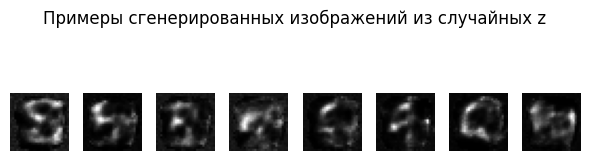

In [16]:
model.eval()
n_samples = 8

# сэмплируем z из N(0, 1)
z_random = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    decoded = model.decoder(z_random)
    decoded = decoded.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(6, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(decoded[i].squeeze(0), cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры сгенерированных изображений из случайных z")
plt.tight_layout()
plt.show()

### Обсуждение качества генерации

Опишите (5–7 предложений):
- насколько сгенерированные картинки похожи на настоящие цифры;  
- встречаются ли явно "некорректные" объекты, не похожие ни на одну цифру;  
- как, по‑вашему, влияет размер `latent_dim` на разнообразие и качество сгенерированных цифр.


In [17]:
gen_comment = """Сгенерированные картинки с трудом можно понять, особенно, если не знаешь, что это вообще такое.
На некоторых изображениях можно увидеть отличительные черты цифры, и только так понять, что это за цифра, но на настоящие цифры они мало похжи.
Есть несколько "некорректных" объектов, которые не похожи ни на одну из цифр, например 1, 3, 8 картинки.
По моему мнению, от размера скрытого слоя зависит разнообразие и качество сгенерированных цифр.
ПРи слишком маленьком размере, модель слишком сжимает картинки, что приведет к размытым, непонятным реконструкциям.
При слишком большом размере, модель будет просто запоминать входные данные, что приведет к хорошей реконструкции, но плохому обобщению.
При умеренном размере будет, так сказать, баланс, и реконструкции будут нормальными и обобщение цифр.
"""
print(gen_comment)

Сгенерированные картинки с трудом можно понять, особенно, если не знаешь, что это вообще такое.
На некоторых изображениях можно увидеть отличительные черты цифры, и только так понять, что это за цифра, но на настоящие цифры они мало похжи.
Есть несколько "некорректных" объектов, которые не похожи ни на одну из цифр, например 1, 3, 8 картинки.
По моему мнению, от размера скрытого слоя зависит разнообразие и качество сгенерированных цифр.
ПРи слишком маленьком размере, модель слишком сжимает картинки, что приведет к размытым, непонятным реконструкциям.
При слишком большом размере, модель будет просто запоминать входные данные, что приведет к хорошей реконструкции, но плохому обобщению.
При умеренном размере будет, так сказать, баланс, и реконструкции будут нормальными и обобщение цифр.



## 9. Задание для самостоятельных вариаций

В **своём** варианте лабораторной вы должны будете:

- попробовать **не меньше двух дополнительных** значений `latent_dim` (например, 2 и 64) и сравнить:  
  - динамику loss,  
  - качество реконструкций,  
  - вид латентного пространства;  
- изменить архитектуру (добавить слои, поменять размеры, попробовать другой activation на скрытых слоях) и кратко описать, что изменилось;  
- оформить итоговые выводы так, чтобы через полгода, открыв ноутбук, вы по нескольким абзацам **вспомнили весь ход экспериментов**.


In [19]:
final_summary = """В своем варианте я попробовала 3 разных изменения(все выводы в файле lab11_experimetns.ipynb): latent_dim=2, latent_dim=128 и latent_dim=16 + 1 слой.
При изначальных настройках модели latent_dim=16, модель показала устойчивое снижение функции потерь до 0.0110.
Увеличив число эпох с 15 до 25 функция потерь снизилась до 0.0103, что немного ниже, чем на 15 эпохах, что может говорить о пределе качества для данной архитектуры.
Подробнее писала выше.

При latent_dim=2 качество реконструкции снизилось, также значение функции потерь стало значительно выше, чем при latent_dim=16 и потери стали = 0.0378.
Это может быть связано, что при сильном сжатии теряются важные детали.

При latent_dim=128 удалось достичь лучших значений функции потерь 0.0078.
Качество реконструкции примерно такое же как и при latent_dim=16.
Однако это может быть и просто запоминание данных, а не обобщение.

При моем ожидание, что снижение latent_dim даст плотное смешивание кластеров, а увеличение, наооборот, не будет смешивать - не подтвердилось.
При latent_dim=2, кластеры, наоборот, лежали довольно кучно и далеко друг от друга, что можно было их разлечить.
При latent_dim=128 кластеры смешались.
Однако каждый размер скрытого слоя объединяло одно - цифра 1 всегда была сгруппирована и выделялась.
"""
print(final_summary)

В своем варианте я попробовала 3 разных изменения(все выводы в файле lab11_experimetns.ipynb): latent_dim=2, latent_dim=128 и latent_dim=16 + 1 слой.
При изначальных настройках модели latent_dim=16, модель показала устойчивое снижение функции потерь до 0.0110.
Увеличив число эпох с 15 до 25 функция потерь снизилась до 0.0103, что немного ниже, чем на 15 эпохах, что может говорить о пределе качества для данной архитектуры.
Подробнее писала выше.

При latent_dim=2 качество реконструкции снизилось, также значение функции потерь стало значительно выше, чем при latent_dim=16 и потери стали = 0.0378. 
Это может быть связано, что при сильном сжатии теряются важные детали.

При latent_dim=128 удалось достичь лучших значений функции потерь 0.0078.
Качество реконструкции примерно такое же как и при latent_dim=16.
Однако это может быть и просто запоминание данных, а не обобщение.

При моем ожидание, что снижение latent_dim даст плотное смешивание кластеров, а увеличение, наооборот, не будет смеши